In [19]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dropout, Dense, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau

# เปิดใช้งาน mixed precision
from tensorflow.keras.mixed_precision import set_global_policy
set_global_policy('mixed_float16')

# โหลดข้อมูลที่เตรียมไว้
data = np.load(r'/home/phatthapol/.vscode-server/ipst_project/prepared_data0.25.npz')
X_train_idx = data['X_train_idx']
y_train = data['y_train']
X_val_idx = data['X_val_idx']
y_val = data['y_val']
thai2vec = data['thai2vec']
max_len = data['max_len']

# สร้างโมเดล LSTM
input_length = int(max_len)
model = Sequential([
    Embedding(input_dim=thai2vec.shape[0], output_dim=thai2vec.shape[1], input_length=input_length, name='embed_layer'),
    Bidirectional(LSTM(128)),
    BatchNormalization(),
    Dropout(0.75),
    Dense(32, activation='relu', kernel_regularizer=l2(0.02)),
    BatchNormalization(),
    Dropout(0.75),
    Dense(5, activation='softmax', dtype='float32')  # output layer should be float32
])

optz = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='sparse_categorical_crossentropy', optimizer=optz, metrics=['accuracy'])
model.build(input_shape=(None, input_length))
model.summary()

model.get_layer('embed_layer').set_weights([thai2vec])
model.get_layer('embed_layer').trainable = True

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.0001)

logs = model.fit(X_train_idx, y_train, epochs=100, batch_size=256,
                 validation_data=(X_val_idx, y_val), callbacks=[reduce_lr])


/home/phatthapol/miniconda3/envs/rapids-24.06/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embed_layer (Embedding)         │ (None, 145, 300)       │    15,407,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_18                │ (None, 256)            │       439,296 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,856,537 (60.49 MB)

 Trainable params: 15,855,961 (60.49 MB)

 Non-trainable params: 576 (2.25 KB)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 309ms/step - accuracy: 0.2291 - loss: 4.1647 - val_accuracy: 0.2128 - val_loss: 2.6682 - learning_rate: 0.0010
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - accuracy: 0.2764 - loss: 3.5519 - val_accuracy: 0.2160 - val_loss: 2.5771 - learning_rate: 0.0010
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step - accuracy: 0.2682 - loss: 3.5080 - val_accuracy: 0.2480 - val_loss: 2.4677 - learning_rate: 0.0010
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.3104 - loss: 3.1266 - val_accuracy: 0.3088 - val_loss: 2.3716 - learning_rate: 0.0010
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 174ms/step - accuracy: 0.3038 - loss: 3.0729 - val_accuracy: 0.3168 - val_loss: 2.3119 - learning_rate: 0.0010
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step - accuracy: 0.3125 - loss: 2.8911 - val_accuracy: 0.3104 - val_loss: 2.2615 - learning_rate: 0.0010
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - accuracy: 0.3360 - loss: 2.7668 - val_ac

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


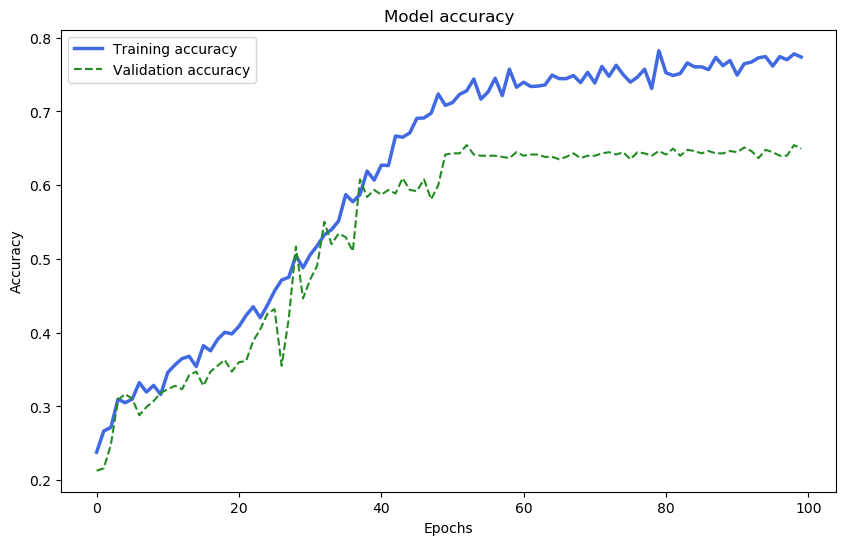

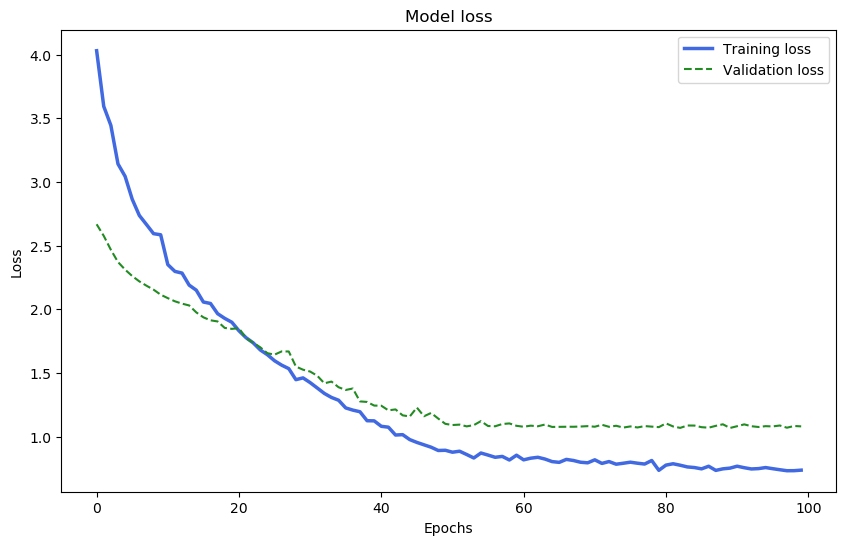

59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step


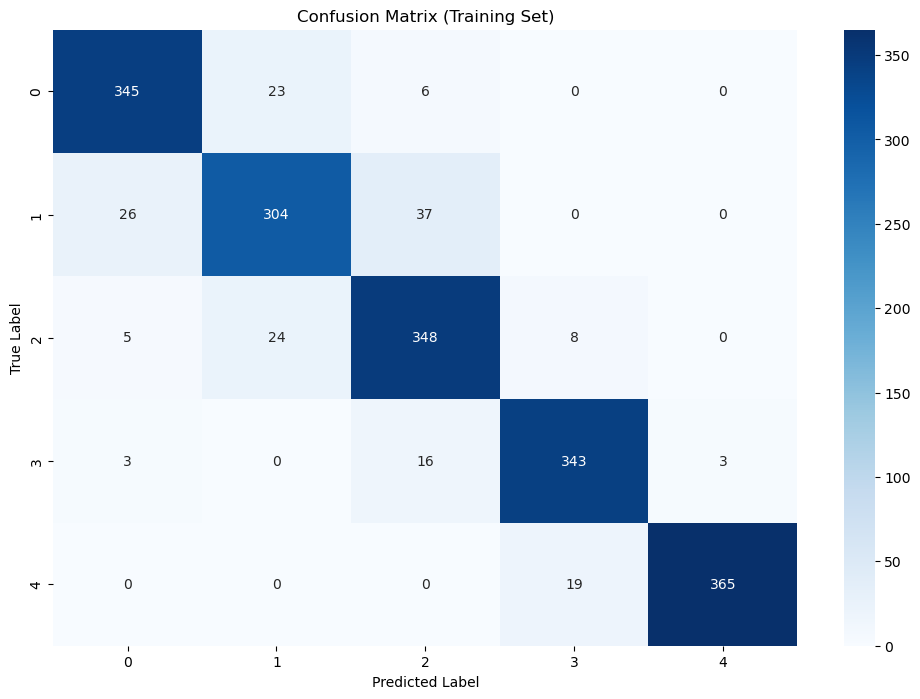

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


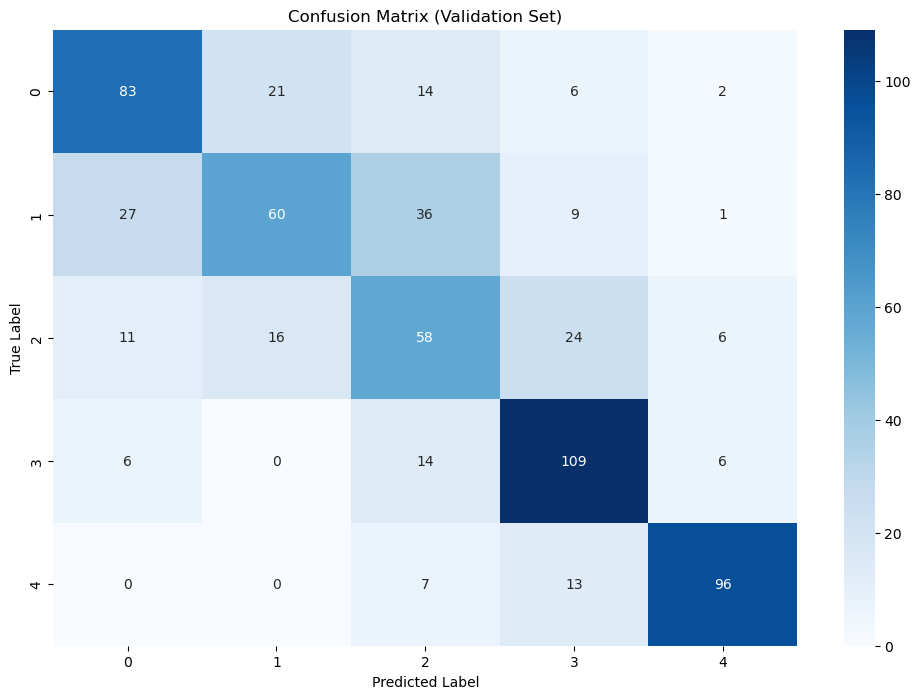

Classification Report: 
              precision    recall  f1-score   support

         0.0       0.65      0.66      0.66       126
         1.0       0.62      0.45      0.52       133
         2.0       0.45      0.50      0.48       115
         3.0       0.68      0.81      0.74       135
         4.0       0.86      0.83      0.85       116

    accuracy                           0.65       625
   macro avg       0.65      0.65      0.65       625
weighted avg       0.65      0.65      0.65       625



In [20]:
import matplotlib.pyplot as plt

# Check available styles
print(plt.style.available)

# Plot training history: accuracy
plt.figure(figsize=(10, 6))
with plt.style.context('_classic_test_patch'):
    plt.title('Model accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.plot(logs.history['accuracy'], c='royalblue', linewidth=2.5, label='Training accuracy')
    plt.plot(logs.history['val_accuracy'], c='forestgreen', linestyle='--', label='Validation accuracy')
    plt.legend(frameon=True, facecolor='white')
    plt.show()

# Plot training history: loss
plt.figure(figsize=(10, 6))
with plt.style.context('_classic_test_patch'):
    plt.title('Model loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.plot(logs.history['loss'], c='royalblue', linewidth=2.5, label='Training loss')
    plt.plot(logs.history['val_loss'], c='forestgreen', linestyle='--', label='Validation loss')
    plt.legend(frameon=True, facecolor='white')
    plt.show()

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
# Prediction and performance for the training set
train_pred = model.predict(X_train_idx).argmax(axis=1)
train_cf_matrix = confusion_matrix(y_train, train_pred)

# Plot confusion matrix for training set
plt.figure(figsize=(12, 8))
plt.title('Confusion Matrix (Training Set)')
sns.heatmap(train_cf_matrix, annot=True, fmt='.0f', cmap=plt.cm.Blues)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

val_pred = model.predict(X_val_idx).argmax(axis=1)
cf_matrix = confusion_matrix(y_val, val_pred)

# Plot confusion matrix
plt.figure(figsize=(12, 8))
plt.title('Confusion Matrix (Validation Set)')
sns.heatmap(cf_matrix, annot=True, fmt='.0f', cmap=plt.cm.Blues)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
report = classification_report(y_val, val_pred)
print(f'Classification Report: \n{report}')

In [21]:
model.save('LSTM1.h5')

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dropout, Dense, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# เปิดใช้งาน mixed precision
from tensorflow.keras.mixed_precision import set_global_policy
set_global_policy('mixed_float16')

# โหลดข้อมูลที่เตรียมไว้
data = np.load(r'/home/phatthapol/.vscode-server/ipst_project/prepared_data0.25.npz')
X_train_idx = data['X_train_idx']
y_train = data['y_train']
X_val_idx = data['X_val_idx']
y_val = data['y_val']
thai2vec = data['thai2vec']
max_len = data['max_len']

# สร้างโมเดล LSTM
input_length = int(max_len)
model = Sequential([
    Embedding(input_dim=thai2vec.shape[0], output_dim=thai2vec.shape[1], input_length=input_length, name='embed_layer'),
    Bidirectional(LSTM(128)),
    BatchNormalization(),
    Dropout(0.75),
    Dense(32, activation='relu', kernel_regularizer=l2(0.02)),
    BatchNormalization(),
    Dropout(0.75),
    Dense(5, activation='softmax', dtype='float32')  # output layer should be float32
])

optz = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='sparse_categorical_crossentropy', optimizer=optz, metrics=['accuracy'])
model.build(input_shape=(None, input_length))
model.summary()

model.get_layer('embed_layer').set_weights([thai2vec])
model.get_layer('embed_layer').trainable = True

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

logs = model.fit(X_train_idx, y_train, epochs=100, batch_size=256,
                 validation_data=(X_val_idx, y_val), callbacks=[reduce_lr, early_stop])


2024-08-24 19:14:48.870504: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-24 19:14:48.894947: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-24 19:14:48.894988: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-24 19:14:48.909301: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-08-24 19:14:49.875776: W tensorflow/compiler/tf

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embed_layer (Embedding)         │ (None, 145, 300)       │    15,407,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       439,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,856,537 (60.49 MB)

 Trainable params: 15,855,961 (60.49 MB)

 Non-trainable params: 576 (2.25 KB)

Epoch 1/100


2024-08-24 19:14:55.734950: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


8/8 ━━━━━━━━━━━━━━━━━━━━ 48s 329ms/step - accuracy: 0.2159 - loss: 3.9825 - val_accuracy: 0.2928 - val_loss: 2.6872 - learning_rate: 0.0010
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 276ms/step - accuracy: 0.2477 - loss: 3.6088 - val_accuracy: 0.2992 - val_loss: 2.5437 - learning_rate: 0.0010
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 273ms/step - accuracy: 0.2704 - loss: 3.4245 - val_accuracy: 0.2976 - val_loss: 2.4572 - learning_rate: 0.0010
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 268ms/step - accuracy: 0.2899 - loss: 3.2478 - val_accuracy: 0.2704 - val_loss: 2.3840 - learning_rate: 0.0010
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 256ms/step - accuracy: 0.2952 - loss: 3.0811 - val_accuracy: 0.2672 - val_loss: 2.3335 - learning_rate: 0.0010
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 252ms/step - accuracy: 0.3050 - loss: 3.0099 - val_accuracy: 0.2800 - val_loss: 2.2862 - learning_rate: 0.0010
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 258ms/step - accuracy: 0.3071 - loss: 2.8198 - val_accuracy: 0.27

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


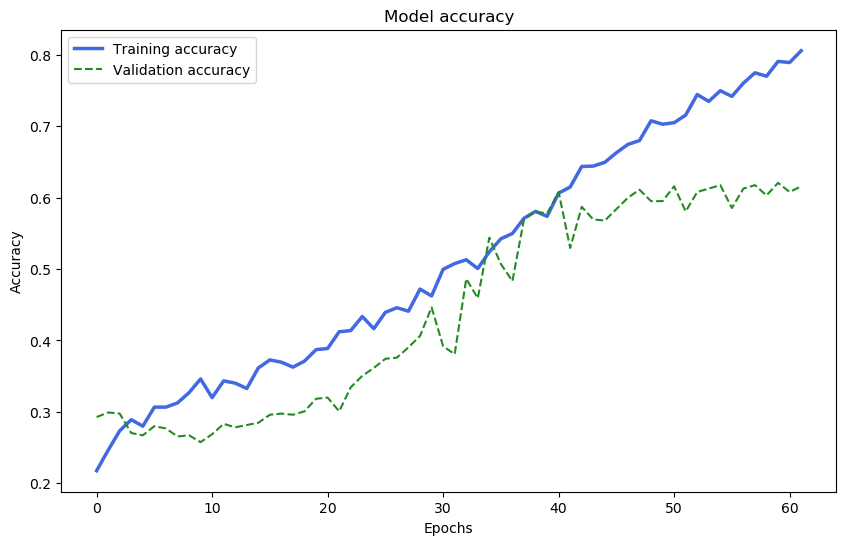

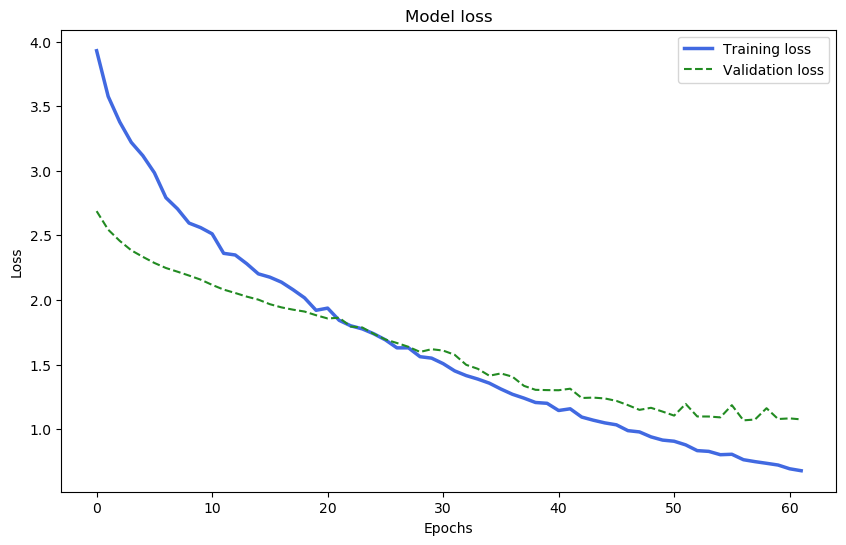

59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step


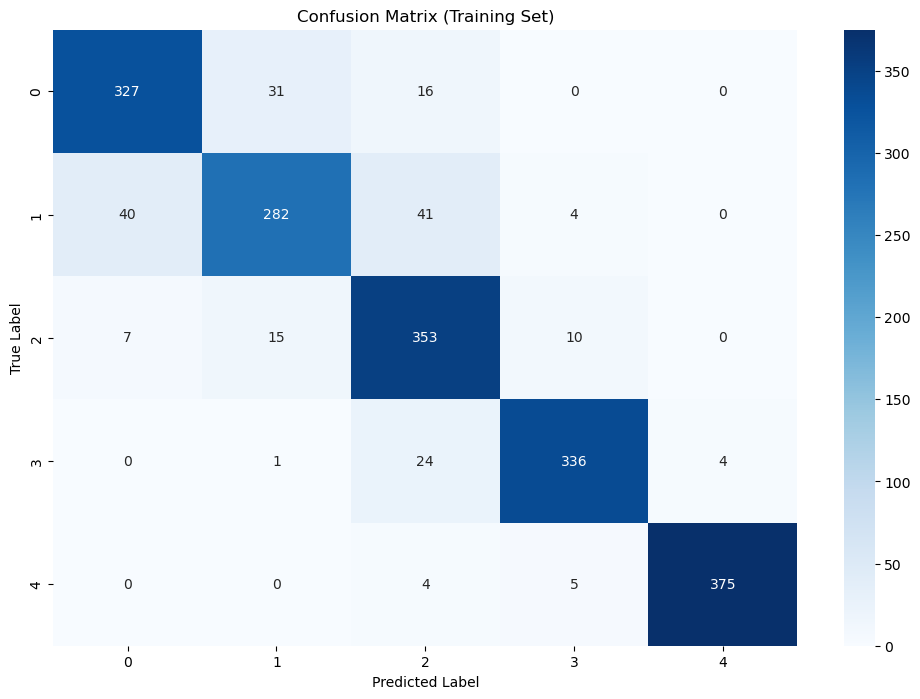

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step


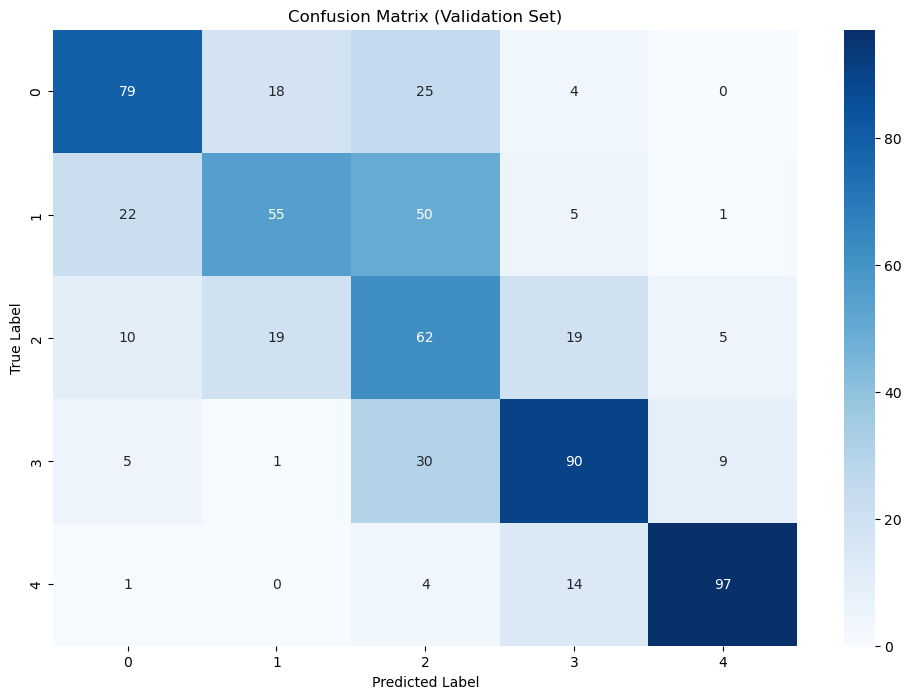

Classification Report: 
              precision    recall  f1-score   support

         0.0       0.68      0.63      0.65       126
         1.0       0.59      0.41      0.49       133
         2.0       0.36      0.54      0.43       115
         3.0       0.68      0.67      0.67       135
         4.0       0.87      0.84      0.85       116

    accuracy                           0.61       625
   macro avg       0.64      0.62      0.62       625
weighted avg       0.64      0.61      0.62       625



In [2]:
import matplotlib.pyplot as plt

# Check available styles
print(plt.style.available)

# Plot training history: accuracy
plt.figure(figsize=(10, 6))
with plt.style.context('_classic_test_patch'):
    plt.title('Model accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.plot(logs.history['accuracy'], c='royalblue', linewidth=2.5, label='Training accuracy')
    plt.plot(logs.history['val_accuracy'], c='forestgreen', linestyle='--', label='Validation accuracy')
    plt.legend(frameon=True, facecolor='white')
    plt.show()

# Plot training history: loss
plt.figure(figsize=(10, 6))
with plt.style.context('_classic_test_patch'):
    plt.title('Model loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.plot(logs.history['loss'], c='royalblue', linewidth=2.5, label='Training loss')
    plt.plot(logs.history['val_loss'], c='forestgreen', linestyle='--', label='Validation loss')
    plt.legend(frameon=True, facecolor='white')
    plt.show()

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
# Prediction and performance for the training set
train_pred = model.predict(X_train_idx).argmax(axis=1)
train_cf_matrix = confusion_matrix(y_train, train_pred)

# Plot confusion matrix for training set
plt.figure(figsize=(12, 8))
plt.title('Confusion Matrix (Training Set)')
sns.heatmap(train_cf_matrix, annot=True, fmt='.0f', cmap=plt.cm.Blues)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

val_pred = model.predict(X_val_idx).argmax(axis=1)
cf_matrix = confusion_matrix(y_val, val_pred)

# Plot confusion matrix
plt.figure(figsize=(12, 8))
plt.title('Confusion Matrix (Validation Set)')
sns.heatmap(cf_matrix, annot=True, fmt='.0f', cmap=plt.cm.Blues)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
report = classification_report(y_val, val_pred)
print(f'Classification Report: \n{report}')

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step


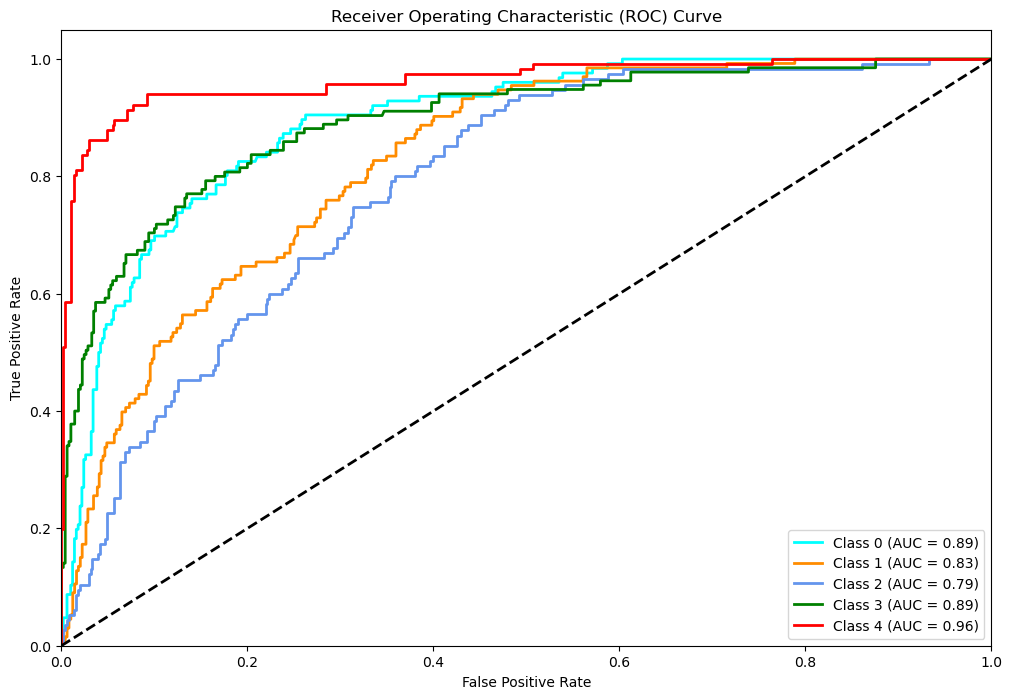

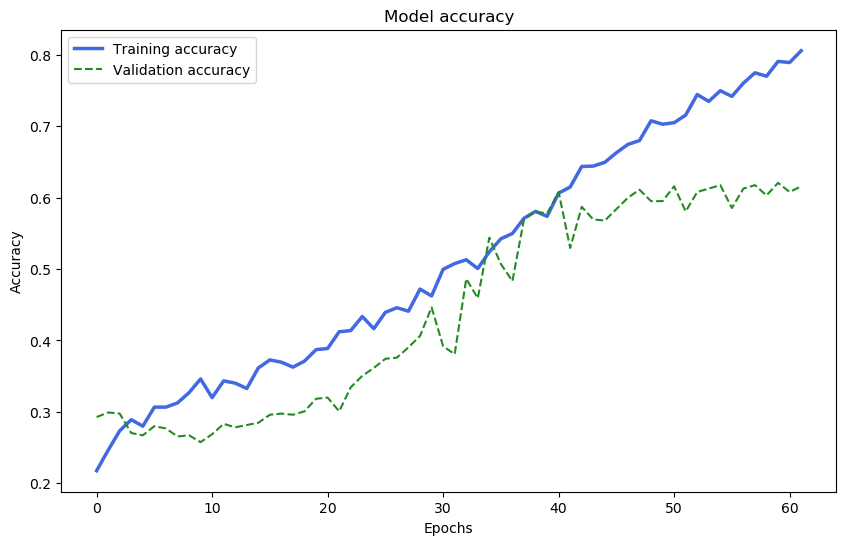

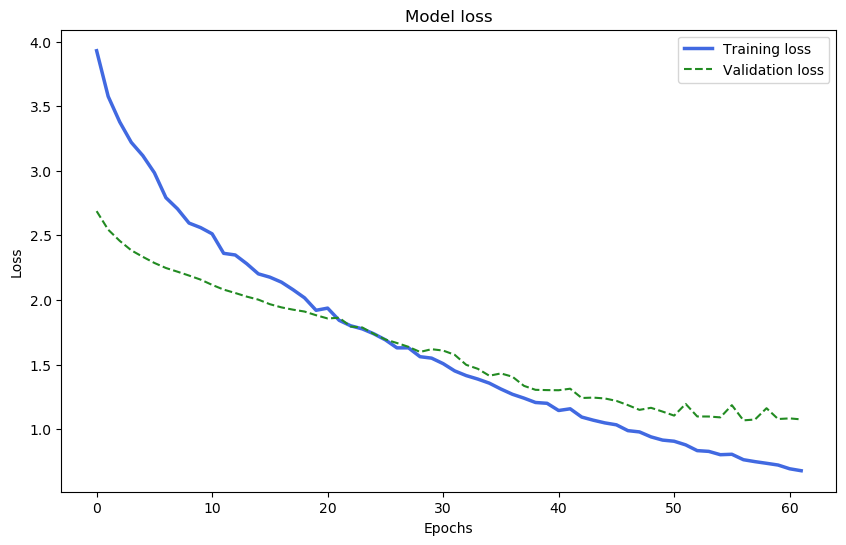

59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step


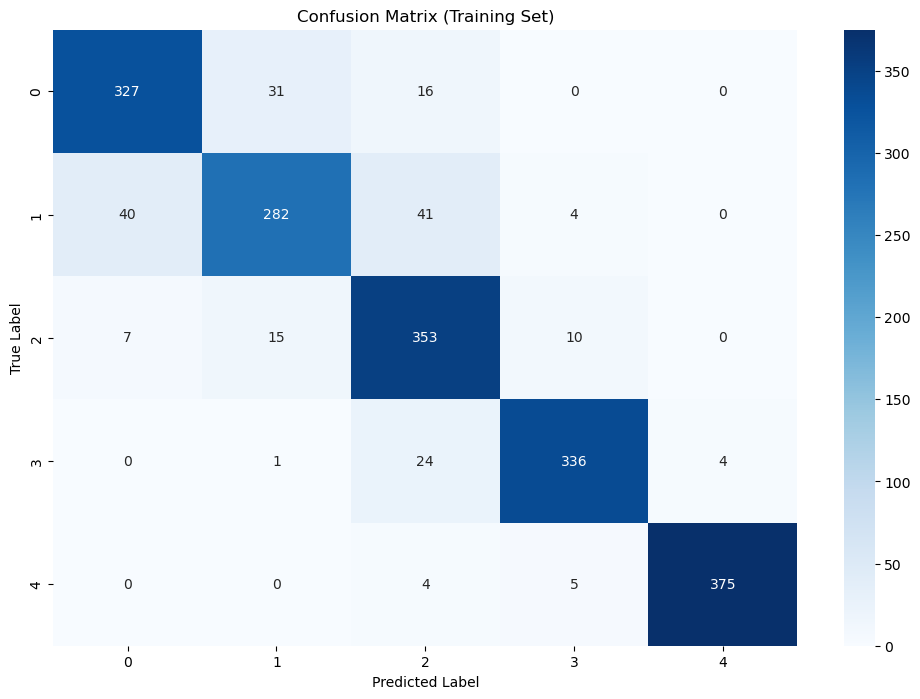

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step


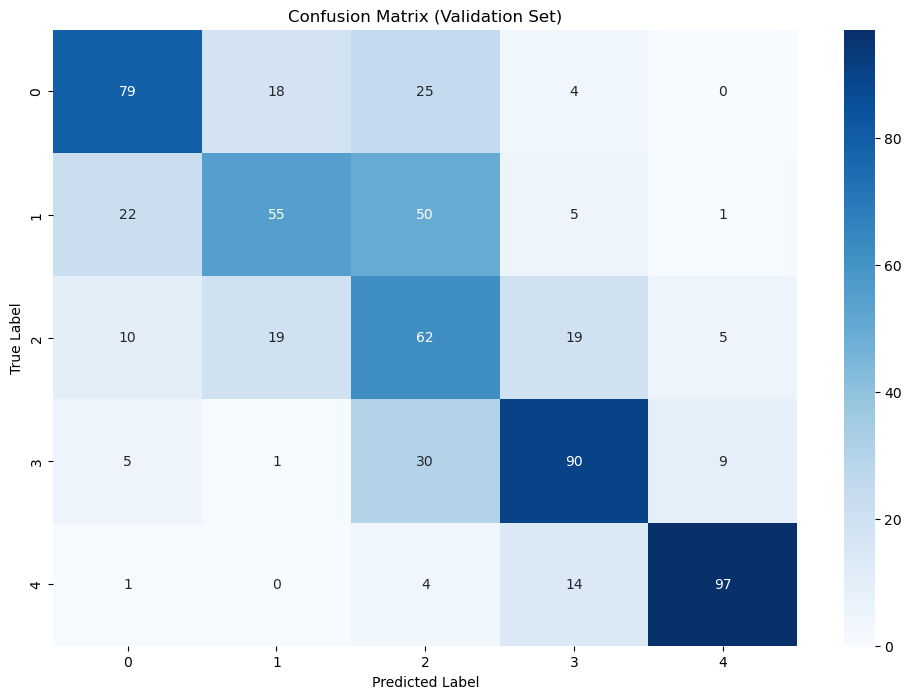

Classification Report: 
              precision    recall  f1-score   support

         0.0       0.68      0.63      0.65       126
         1.0       0.59      0.41      0.49       133
         2.0       0.36      0.54      0.43       115
         3.0       0.68      0.67      0.67       135
         4.0       0.87      0.84      0.85       116

    accuracy                           0.61       625
   macro avg       0.64      0.62      0.62       625
weighted avg       0.64      0.61      0.62       625



In [3]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle

# Assuming y_val and val_pred are the true labels and predicted labels respectively
# Assuming you have multiple classes, binarize the output
n_classes = len(set(y_val))
y_val_bin = label_binarize(y_val, classes=[i for i in range(n_classes)])
val_pred_prob = model.predict(X_val_idx)  # Predicted probabilities

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], val_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure(figsize=(12, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple'])  # Adjust number of colors to match n_classes

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Plot training history: accuracy
plt.figure(figsize=(10, 6))
with plt.style.context('_classic_test_patch'):
    plt.title('Model accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.plot(logs.history['accuracy'], c='royalblue', linewidth=2.5, label='Training accuracy')
    plt.plot(logs.history['val_accuracy'], c='forestgreen', linestyle='--', label='Validation accuracy')
    plt.legend(frameon=True, facecolor='white')
    plt.show()

# Plot training history: loss
plt.figure(figsize=(10, 6))
with plt.style.context('_classic_test_patch'):
    plt.title('Model loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.plot(logs.history['loss'], c='royalblue', linewidth=2.5, label='Training loss')
    plt.plot(logs.history['val_loss'], c='forestgreen', linestyle='--', label='Validation loss')
    plt.legend(frameon=True, facecolor='white')
    plt.show()

# Prediction and performance for the training set
train_pred = model.predict(X_train_idx).argmax(axis=1)
train_cf_matrix = confusion_matrix(y_train, train_pred)

# Plot confusion matrix for training set
plt.figure(figsize=(12, 8))
plt.title('Confusion Matrix (Training Set)')
sns.heatmap(train_cf_matrix, annot=True, fmt='.0f', cmap=plt.cm.Blues)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

val_pred = model.predict(X_val_idx).argmax(axis=1)
cf_matrix = confusion_matrix(y_val, val_pred)

# Plot confusion matrix
plt.figure(figsize=(12, 8))
plt.title('Confusion Matrix (Validation Set)')
sns.heatmap(cf_matrix, annot=True, fmt='.0f', cmap=plt.cm.Blues)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Print classification report
report = classification_report(y_val, val_pred)
print(f'Classification Report: \n{report}')
